In [1]:
subset = True
subset_size = 0.05

In [2]:
import os
import time

import pandas as pd
import numpy as np
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import preprocess as pp 
from scLEMBAS.model.train import TrainSC
from scLEMBAS.model.scl import SignalingModel

from Tahoe_utils import Tahoe100M_split

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/nobackup/


[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] W

In [3]:
n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888
mod_seed = 888
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
author = 'Tahoe100M'

device = "cuda" if torch.cuda.is_available() else "cpu"

Load data:

In [4]:
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', author + '_sn_ppis.csv'), 
                     index_col = 0)
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

tf_adata = io.read_tfad(os.path.join(data_path, 'processed', author + '_consensus_tf_activity.h5ad'))
adata = sc.read_h5ad(os.path.join(data_path, 'processed', author + '_expr_in.h5ad'))
expr = adata.to_df().copy()

# basic formatting checks
if not np.all(tf_adata.var_names == sorted(tf_adata.var_names)):
    raise ValueError('Ensure TF adata features are sorted on input')
    
if not np.all(adata.obs_names == tf_adata.obs_names):
    raise ValueError('Ensure gene expression and TF activity sample features are orderd the same')
    
if len(set(tf_adata.obs.drug)) != len(tf_adata.obs.drug.cat.categories):
    raise ValueError('Make sure only present perturbations are in the categorical columns')
    
if len(set(tf_adata.obs.cell_line)) != len(tf_adata.obs.cell_line.cat.categories):
    raise ValueError('Make sure only present cell lines are in the categorical columns')

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Train/test split:

In [5]:
train_split, test_split = Tahoe100M_split(tf_adata,
                                          train_frac = 0.9, 
                                          min_drug_frac = 0.7, 
                                          min_cell_line_frac = 0.7, 
                                          exclude_control = True, 
                                          max_attempts = 1000, 
                                          seed = seed)

train_cells = train_split['barcodes']
test_cells = test_split['barcodes']

cell_line_counts = pd.DataFrame({
    'train': train_split['cell_line_counts'],
    'test': test_split['cell_line_counts']
}).sort_values(by = 'train', ascending = True)

drug_counts = pd.DataFrame({
    'train': train_split['drug_counts'],
    'test': test_split['drug_counts']
}).sort_values(by = 'train', ascending = True)



In [6]:
cell_line_counts

,train,test
cell_line,,
CVCL_0371,23,6
CVCL_0546,24,5
CVCL_1056,24,5
CVCL_0480,26,3
CVCL_1550,26,3
CVCL_0459,27,2
CVCL_1285,27,2
CVCL_0023,28,1
CVCL_0399,28,1


In [7]:
drug_counts

,train,test
drug,,
Neratinib (maleate),8,2
Almonertinib (mesylate),8,2
Tofacitinib (citrate),8,2
Rucaparib (phosphate),8,2
Retinoic acid,8,2
Rapamycin,8,2
Norepinephrine (hydrochloride),8,2
Filgotinib,8,2
Tofacitinib,9,1


In [8]:
if subset:
    train_cells = []
    np.random.seed(seed)
    for cond in train_split['conditions'].condition:
        subset_cond = tf_adata.obs[tf_adata.obs.condition == cond]
        subset_cells = list(np.random.choice(
            subset_cond.index,
            size = int(np.round(subset_cond.shape[0] * subset_size)),
            replace = False
        ))
        train_cells+=subset_cells
    tf_adata = tf_adata[tf_adata.obs_names.isin(train_cells + test_cells),:].copy()
    adata = adata[tf_adata.obs_names, :].copy()
    expr = adata.to_df().copy()

**Note: As mentioned in Notebook 00A, when splitting the data into train-test splits, conditions will remain balanced, but drug/cell lines will not be completely balanced (due to OOD, cannot ensure the drug and cell line split is the same as the condition split).** 

# Hyper-parameters:

In [9]:
def generate_lr_params(n_epochs, 
                       max_lr, 
                       lr_scaling_factor=10, 
                       lr_decay=0.75,
                       n_restarts = 4,
                       n_discriminator_train=5, 
                       n_adversarial_start = 0,
                       role='scl'):
    """
    Generate LR scheduler params for WarmupCosineAnnealingWarmRestarts
    that ensures discriminator and generator follow the same curve in real (epoch) time.

    Parameters:
        - n_epochs: total training epochs
        - max_lr: peak learning rate
        - lr_scaling_factor: factor to determine min LR
        - lr_decay: gamma decay per restart
        - n_restarts: desired number of cosine peaks (n_restarts)
        - n_adversarial_start: epoch when adversarial training begins
        - n_discriminator_train: frequency of discriminator training relative to generator
        - role: 'scl' or discriminator' or 'generator'

    Returns:
        Dict of scheduler parameters
    """
    
    
    
    total_active_epochs = n_epochs
    n_discriminator_train_ = 1
    if role in ['discriminator', 'generator']:
        total_active_epochs = n_epochs - n_adversarial_start
        if role == 'generator':
            n_discriminator_train_ = n_discriminator_train
            
#     n_restarts = 4 if total_active_epochs // n_discriminator_train_ > 500 else 2


    T_0 = max(1, (total_active_epochs // n_discriminator_train_) // n_restarts)
    warmup_epochs = max(1, (total_active_epochs // n_discriminator_train_) // 10)

#     if reset_state:
#         if total_active_epochs // n_discriminator_train_ > 400:
#             n_optimizer_resets = 2
#         elif total_active_epochs // n_discriminator_train_ < 100:
#             n_optimizer_resets = 0
#         else:
#             n_optimizer_resets = 1
#     else:
#         n_optimizer_resets = 0
        
    if warmup_epochs >= T_0:
        warmup_epochs = 0

    return {
        'max_epochs': n_epochs,
        'maximum_learning_rate': max_lr,
        'minimum_learning_rate': max_lr / lr_scaling_factor,
        'lr_restart_epoch': T_0,  
        'n_optimizer_resets': 0,  # no longer used
        'lr_decay': lr_decay,
        'lr_restart_factor': 1,
        'warmup_epochs': warmup_epochs
    }

In [10]:
projection_amplitude_in = 10
projection_amplitude_out = 1

bionet_params = {'target_steps': 100, 
                 'max_steps': 120, 
                 'exp_factor': 50, 
                 'tolerance': 1e-5, 
                 'leak': 1e-2}

spectral_radius_params = {'n_probes_spectral': 5, 
                          'power_steps_spectral': 5, 
                          'subset_n_spectral': 5}
target_spectral_radius = 0.9

noise_params = {
    'network_noise_scale': 0.01, 
    'min_network_noise': 0.0015, #0.0025, 
    'gradient_noise_scale': 1e-9, 
    'include_gradient_noise_vae': True, 
    'include_gradient_noise_embedding': True, 
    'constant_gradient_noise': True
    
}

In [11]:
loss_scaler = 100
prediction_loss_fn = torch.nn.MSELoss(reduction='mean')
per_condition_loss = False # TODO: check this


batch_params = {
    'train_batch_size': int(512*8), 
    'test_batch_size': int(512*8), 
    'validation_batch_size': np.nan
}

if subset:
    if subset_size < 0.02:
        batch_params['train_batch_size'] = int(512*2)
        batch_params['test_batch_size'] = int(512*2)
    else:
        batch_params['train_batch_size'] = int(512*8)
        batch_params['train_batch_size'] = int(512*8)
    


max_epochs = 600


max_lr = 0.001
lr_scaling_factor = 10
lr_decay = 0.75
n_restarts = 4
lr_params = generate_lr_params(n_epochs = max_epochs, 
                               max_lr = max_lr, 
                               lr_scaling_factor = lr_scaling_factor, 
                               lr_decay = lr_decay,
                               n_restarts = n_restarts,
                               n_adversarial_start = np.nan, 
                               n_discriminator_train = np.nan, 
                               role = 'scl')

# reset_state = False # DEPRECATED
# initialize_fc = True # DEPRECATED

In [12]:
bionet_params['cat_max_norm'] = 100
regularization_params = {
    'input_lambda_L2': 0, # irrelevant because setting the requires grad to False
    
    'bn_weights_lambda_L2': 1e-7,
    'moa_lambda_L1': 1e2,
    'uniform_lambda_L2': 1e-7, 
    'uniform_min': -1/projection_amplitude_out,
    'uniform_max': 1/projection_amplitude_out,
    'adj_scaling_KL': 0,  # using uniform/bn_weights already
    'adj_prior_mu': 0, # irrelevant because adj_scaling_KL is 0
    'adj_prior_sigma': 0.2, # irrelevant because adj_scaling_KL is 0
    
    'output_weights_lambda_L2': 1e-7,
    'output_bias_lambda_L2': 1e-7,
    
    'spectral_loss_factor': 1e-6,
    
    
    'global_bias_lambda_L2': 0, # using KL divergence instead
    'global_bias_lambda_L1': 0, # using KL divergence instead
    'cat_bias_lambda_L2': 0, # using cat max norm
    'cat_bias_lambda_L1': 0, # using cat max norm
    'cat_bias_orthogonality_scaler': 0
}

In [13]:
training_params = {
    **lr_params, 
    **batch_params, 
    **regularization_params, 
    **spectral_radius_params,
    **noise_params
}

training_params['prediction_loss_fn_scaler'] = loss_scaler

VAE:

In [14]:
# building
n_layers_vae = 1
n_nodes = len(set(sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist()))
vae_n_hidden_nodes = list(np.round(np.linspace(adata.shape[1], n_nodes, n_layers_vae + 2)).astype(int)[1:-1])

generator_dropout_rate = 0.7
vae_mod_params = {
    'vae_batch_momentum': 0.01, 
    'vae_layer_norm': False, 
    'vae_dropout_rate': generator_dropout_rate,
    'vae_activation_fn': nn.LeakyReLU,
    'vae_n_hidden_nodes': vae_n_hidden_nodes, 
    'vae_var_min': 1e-4

} 
bionet_params = {**bionet_params, **vae_mod_params}

# training
vae_params = {
    'prior_mu': 0, 
    'prior_sigma': 1,
    'scaling_KL': 1e-2, 
    'lambda_l2': 1e-5, 
    'optimizer': torch.optim.Adam
}

n_adversarial_start = 0 
n_discriminator_train = 5
n_restarts_adversarial = 4
vae_lr_params = generate_lr_params(n_epochs = max_epochs,
                                   max_lr = max_lr,
                                   lr_scaling_factor = lr_scaling_factor, 
                                   lr_decay = lr_decay,
                                   n_restarts = n_restarts_adversarial,
                                   n_adversarial_start = n_adversarial_start, 
                                   n_discriminator_train = n_discriminator_train,
                                   role = 'generator')
vae_params = {**vae_params, **vae_lr_params}
del vae_params['max_epochs']


Discriminator:

In [15]:
discriminator_dropout_rate = 0.3
discriminator_lambda_L2 = 1e-3

discriminator_params = {
    'batch_momentum': None,
    'layer_norm': False,
    'spectral_norm': False,
    'dropout_rate': discriminator_dropout_rate,
    'activation_fn': nn.LeakyReLU,
    'n_hidden_nodes': np.nan,
    'lr_restart_factor': 1,
    'optimizer': torch.optim.Adam,
    'discriminator_lambda_L2': discriminator_lambda_L2,
    'discriminator_penalty_weight': np.nan, 
    'bionet_activation': False,
    'smooth_labels': True, 
    'epsilon_smooth': np.nan
}

discriminator_lr_params = generate_lr_params(
    n_epochs = max_epochs,
    max_lr = max_lr,
    lr_scaling_factor = lr_scaling_factor, 
    lr_decay = lr_decay,
    n_restarts = n_restarts_adversarial,
    n_adversarial_start = n_adversarial_start, 
    n_discriminator_train = n_discriminator_train,
    role = 'discriminator')
del discriminator_lr_params['max_epochs']

discriminator_params = {**discriminator_params, **discriminator_lr_params}

In [16]:
# architecture
n_layers_disc = 3
cat_disc_n_hidden_nodes = list(np.round(np.linspace(n_nodes, 
                                                    cell_line_counts.shape[0],
                                                    n_layers_disc + 2)).astype(int)[1:-1])
cat_discriminator_params = discriminator_params.copy()
cat_discriminator_params['n_hidden_nodes'] = cat_disc_n_hidden_nodes


pert_disc_n_hidden_nodes = list(np.round(np.linspace(n_nodes, 
                                                     drug_counts.shape[0], 
                                                     n_layers_disc + 2)).astype(int)[1:-1])
pert_discriminator_params = discriminator_params.copy()
pert_discriminator_params['n_hidden_nodes'] = pert_disc_n_hidden_nodes


cat_discriminator_params['epsilon_smooth'] = 1/tf_adata.obs.cell_line.nunique()
pert_discriminator_params['epsilon_smooth'] = 1/tf_adata.obs.drug.nunique()

In [17]:
# adverserial penalty curve
cat_max_penalty_weight = 11
cat_b_adv = 2.5
pert_max_penalty_weight = 15
pert_b_adv = 10#4

cat_discriminator_penalty_weight = pp.discriminator_weight_curve(
    n_epochs = max_epochs - n_adversarial_start,
    min_penalty_weight = 0.1,
    max_penalty_weight = cat_max_penalty_weight,
    a = 1,
    b = cat_b_adv, 
    curve_type = 'power')
cat_discriminator_params['discriminator_penalty_weight'] = cat_discriminator_penalty_weight

pert_discriminator_penalty_weight = pp.discriminator_weight_curve(
    n_epochs = max_epochs - n_adversarial_start,
    min_penalty_weight = 0.1,
    max_penalty_weight = pert_max_penalty_weight,
    a = 1,
    b = pert_b_adv, 
    curve_type = 'power')
pert_discriminator_params['discriminator_penalty_weight'] = pert_discriminator_penalty_weight



In [18]:
pert_discriminator_params['discriminator_penalty_weight'] = [0]*max_epochs

Visualize hyperparameters:

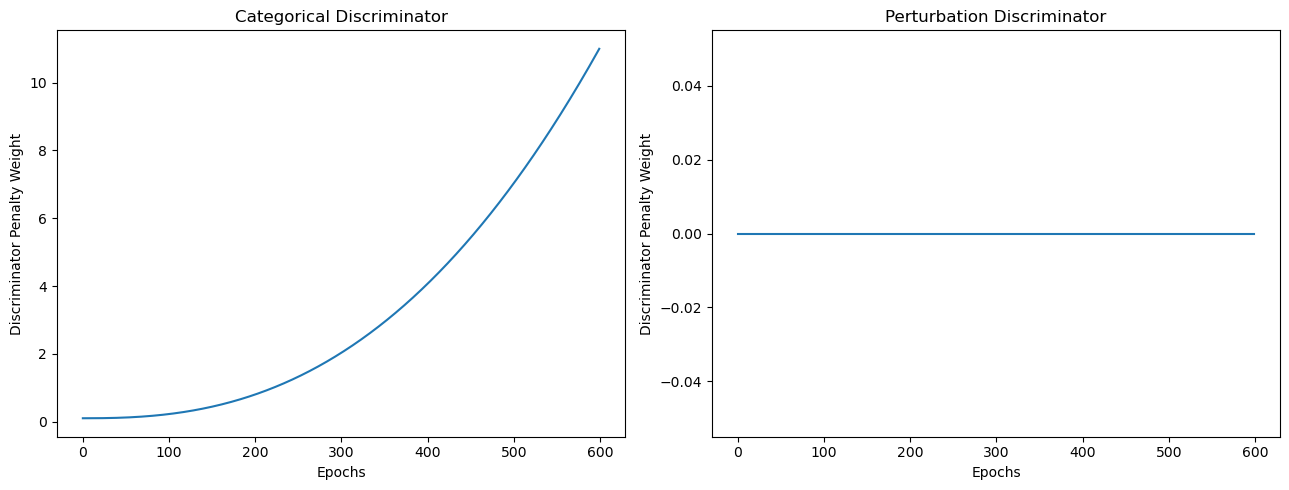

In [19]:
fig, ax = plt.subplots(ncols = 2, figsize = (13,5))
sns.lineplot(cat_discriminator_params['discriminator_penalty_weight'], ax = ax[0])
ax[0].set_title('Categorical Discriminator')

sns.lineplot(pert_discriminator_params['discriminator_penalty_weight'], ax = ax[1])
ax[1].set_title('Perturbation Discriminator')

for i in range(2):
    ax[i].set_xlabel('Epochs')
    ax[i].set_ylabel('Discriminator Penalty Weight')
    
fig.tight_layout();

# Build model and trainer

In [20]:
# input stimulation
X_in = pd.get_dummies(tf_adata.obs.drug).astype(int)
X_in.drop(columns = 'DMSO_TF', inplace = True) # all 0s

In [21]:
mod = SignalingModel(
    net = sn_ppis,
    X_in = X_in,
    y_out = tf_adata.to_df().copy(), 
    expr = expr, 
    covariates = tf_adata.obs.copy(),
    categorical_covariate_keys = ['cell_line'],
    projection_amplitude_in = projection_amplitude_in, 
    projection_amplitude_out = projection_amplitude_out,
    weight_label = weight_label, source_label = source_label, target_label = target_label,
    bionet_params = bionet_params, 
    dtype = torch.float32, device = device, seed = mod_seed)

mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius


In [22]:
trainer = TrainSC(
    mod = mod,
    prediction_optimizer = torch.optim.Adam,
    prediction_loss_fn = prediction_loss_fn, 
    per_condition_loss = per_condition_loss,
    n_adversarial_start = n_adversarial_start, 
    n_discriminator_train = n_discriminator_train,
    gradient_ascent = True,
    cat_discriminator_params = cat_discriminator_params,
    pert_discriminator_params = pert_discriminator_params,
    vae_params = vae_params,
    hyper_params = training_params,
    train_split = {'train': train_cells, 'test': test_cells, 'validation': None}, 
    train_seed = mod_seed, 
    track_test = True,
    track_validation = False, 
    n_eval_cells = np.nan, 
    n_eval_bootstrap = np.nan
)

In [23]:
fn = 'no_pert_adv_'

if not os.path.isfile(os.path.join(data_path, 'trash', fn + author +  '_trainer.pickle')):

    mod = trainer.train_model(verbose = True)

    io.write_pickled_object(trainer, os.path.join(data_path, 'trash', fn + author +  '_trainer.pickle'))

  0%|                                 | 1/600 [00:10<1:42:23, 10.26s/it]

i=0, l(tr)=90.11140, l(te)=nan, s=0.14848, r=0.00010, v=0.00000


  1%|▍                                | 7/600 [01:06<1:32:33,  9.36s/it]

i=6, l(tr)=60.31939, l(te)=nan, s=0.08805, r=0.00019, v=0.00000


  2%|▋                               | 13/600 [02:01<1:30:41,  9.27s/it]

...

i=588, l(tr)=35.36402, l(te)=nan, s=0.20936, r=0.00025, v=0.14286


 99%|██████████████████████████████▋| 595/600 [1:58:55<01:07, 13.45s/it]

i=594, l(tr)=35.40700, l(te)=nan, s=0.17547, r=0.00023, v=0.14286


100%|███████████████████████████████| 600/600 [1:59:59<00:00, 12.00s/it]


Training ran in: 119 min 59.50 sec


# Checkpoint

In [24]:
tf_adata = io.read_tfad(os.path.join(data_path, 'processed', author + '_consensus_tf_activity.h5ad'))
trainer = io.read_pickled_object(os.path.join(data_path, 'trash', fn + author +  '_trainer.pickle'))

n_discriminator_train = trainer.n_discriminator_train
n_adversarial_start = trainer.n_adversarial_start

mod = trainer.mod
if torch.isinf(mod.signaling_network.weights).any():
    raise ValueError('Exploding gradients')

train_stats_df = trainer.stats['train'].copy()

# NaN untrained discrimintor epochs for visualization purposes
keep_idx = (train_stats_df.epoch - 1) % n_discriminator_train == 0
for col in ['global_bias_kl_divergence', 'vae_param_reg_loss', 'vae_grad_l2_norm', 
           'cat_adverserial_loss', 'pert_adverserial_loss']:
    train_stats_df[col] = train_stats_df[col].mask(
        (~keep_idx) & (train_stats_df[col] == 0),  # this second condition is a sanity check, shouldn't be necessary
        np.nan
    )
    
# since total is a function of adversarial parameters that also go to 0 on n_discriminator train
for col in ['train_loss_total']:
    train_stats_df[col] = train_stats_df[col].mask(
        (~keep_idx), 
        np.nan
    )
    
# similarly, sign reg goes to 0 with 0 violations which makes visualization difficult
# we will ignore those for a smoother curve
for col in ['sign_reg_loss']:
    train_stats_df[col] = train_stats_df[col].mask(
        (train_stats_df[col] == 0), 
        np.nan
    )


train_stats_df = train_stats_df.groupby('epoch').mean().reset_index() # delete this
    
cat_col = 'cell_line'
pert_col = 'drug'
    
train_cells = trainer.X_train.index.tolist()
test_cells = trainer.X_test.index.tolist()

train_conds = sorted(tf_adata.obs.loc[train_cells, :].condition.unique())
test_conds = sorted(tf_adata.obs.loc[test_cells, :].condition.unique())

## 1. Basic Curves

In [25]:
from matplotlib.lines import Line2D
import math

### Learning Rate + MOA

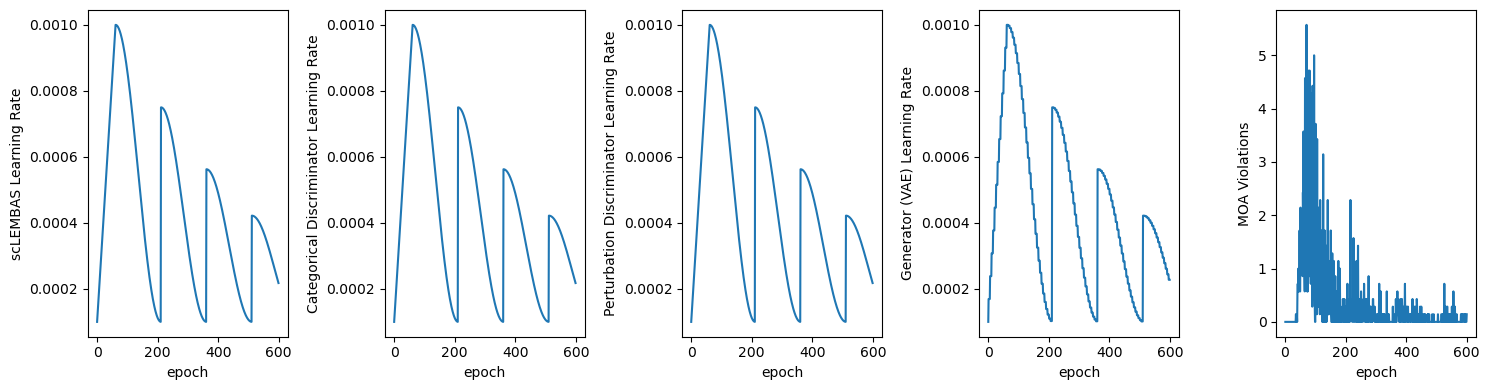

In [26]:
viz_df = train_stats_df.copy()
viz_df.epoch -= 1
fig, ax = plt.subplots(ncols = 5, figsize = (15, 4))

sns.lineplot(data = viz_df, x = 'epoch', y = 'learning_rate', ax = ax[0])
ax[0].set_ylabel('scLEMBAS Learning Rate')

sns.lineplot(data = viz_df, x = 'epoch', y = 'cat_discriminator_learning_rate', ax = ax[1])
ax[1].set_ylabel('Categorical Discriminator Learning Rate')

sns.lineplot(data = viz_df, x = 'epoch', y = 'pert_discriminator_learning_rate', ax = ax[2])
ax[2].set_ylabel('Perturbation Discriminator Learning Rate')

sns.lineplot(data = viz_df, x = 'epoch', y = 'vae_learning_rate', ax = ax[3])
ax[3].set_ylabel('Generator (VAE) Learning Rate')

sns.lineplot(data = train_stats_df, x = 'epoch', y = 'n_moa_violations', ax = ax[4])
ax[4].set_ylabel('MOA Violations')

for i in [1, 2, 3]:
    if n_adversarial_start != 0:
        ax[i].vlines(n_adversarial_start, 
                     ymin = 0, 
                     ymax = ax[i].get_ylim()[1], color = 'red', linestyle = '--')


fig.tight_layout()
# plt.savefig(os.path.join(data_path, 'trash', fn + '_loss_epochs' + '.png'), dpi=300, bbox_inches='tight')


### Training Loss + Regularization

/tmp/ipykernel_2921168/1171987059.py:68: UserWarning: The palette list has more values (12) than needed (10), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[i])
/tmp/ipykernel_2921168/1171987059.py:104: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  zeros = viz_df.groupby('loss_type').loss.apply(lambda x: (x == 0).all())
/tmp/ipykernel_2921168/1171987059.py:154: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


''

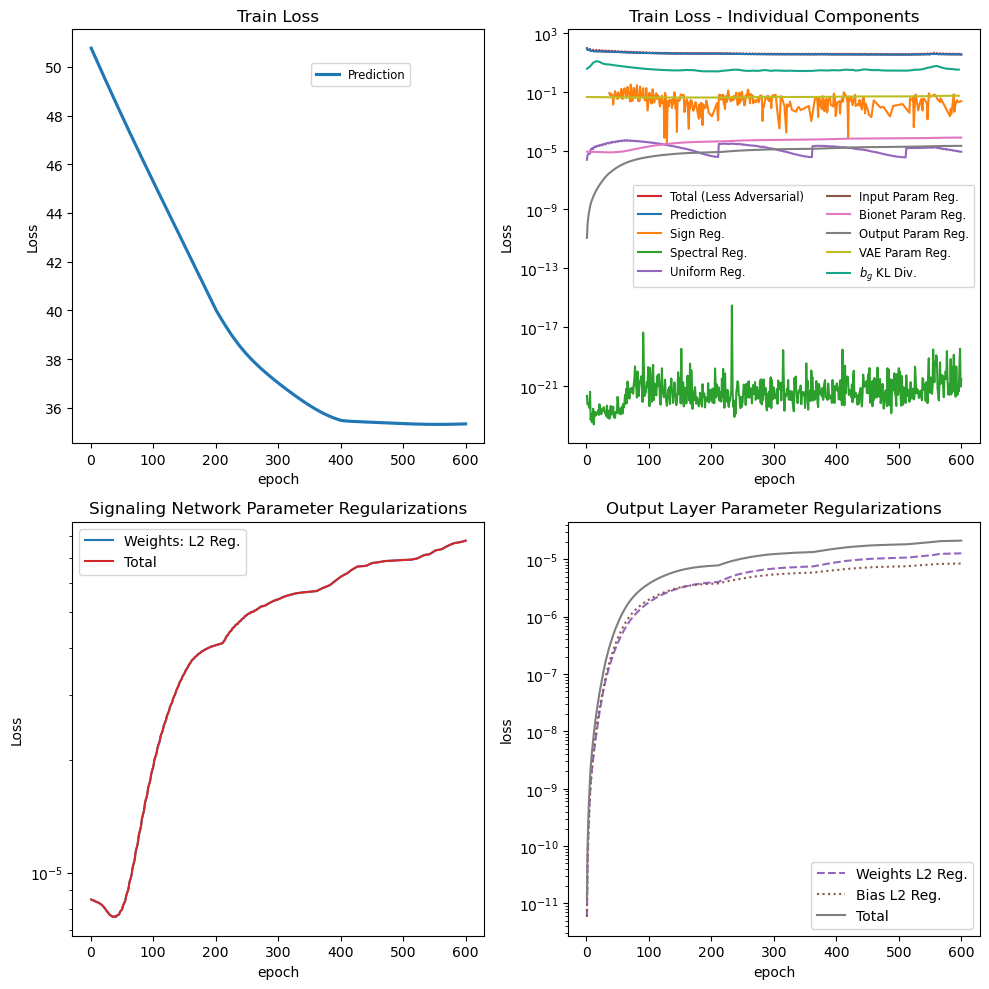

In [27]:
fig, axes = plt.subplots(ncols = 2, nrows = 2, figsize = (10, 10), 
                        constrained_layout=True)
ax = axes.flatten()

colors = [
    "#d62728",  # Red
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#bcbd22",  # Olive
    "#17a589",  #  Teal 
    "#6baed6",  # light blue
    "#ff9896"   # Light red
]
palette = sns.color_palette(colors)

# prediction loss
i = 0

loss_cols_main = [
       'train_loss_prediction', 'sign_reg_loss',
       'stability_reg_loss', 'uniform_reg_loss', 'input_param_reg_loss',
       'sn_param_reg_tot_loss', 'output_param_reg_tot_loss', 'vae_param_reg_loss', 
    'global_bias_kl_divergence']

viz_df = train_stats_df[['epoch'] + loss_cols_main].copy()
viz_df['total_train_loss_no_adverserial'] = viz_df[loss_cols_main].sum(axis = 1)
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, 
                                  categories=['total_train_loss_no_adverserial'] + loss_cols_main)


loss_map = {
    'train_loss_prediction': 'Prediction', 
    'sign_reg_loss': 'Sign Reg.', 
    'stability_reg_loss': 'Spectral Reg.', 
    'uniform_reg_loss': 'Uniform Reg.', 
    'input_param_reg_loss': 'Input Param Reg.', 
    'sn_param_reg_tot_loss': 'Bionet Param Reg.', 
    'output_param_reg_tot_loss': 'Output Param Reg.', 
    'vae_param_reg_loss': 'VAE Param Reg.', 
    'global_bias_kl_divergence': r'$b_g$' + ' KL Div.', 
    'total_train_loss_no_adverserial': 'Total (Less Adversarial)'
}
viz_df.loss_type = viz_df.loss_type.map(loss_map)


loss_cols_sub = ['Total (No Adversarial)', 'Prediction']

# viz_df = viz_df[viz_df.loss_type.isin(loss_cols_sub)]
# viz_df.loss_type = viz_df.loss_type.cat.remove_unused_categories()

for lti, loss_type in enumerate(loss_cols_sub):
    sns.regplot(data = viz_df[viz_df.loss_type == loss_type], 
                x = 'epoch', y = 'loss', 
                lowess = True, scatter = False, 
                color = palette[lti], ax = ax[i], label = loss_type)
ax[i].legend(loc='lower center', bbox_to_anchor=(0.7, 0.85), ncol = 1, fontsize = 'small')
ax[i].set_title('Train Loss')

# all losses
i = 1

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[i])
ax[i].legend(ncol = 2, fontsize = 'small')
ax[i].set_title('Train Loss - Individual Components')
ax[i].set_yscale('log')


# signaling network weights and bias by individual components (except global bias KL divergence visualized above)
i = 2
loss_cols = [
    'sn_param_reg_tot_loss',
    'sn_param_reg_weights_L2_loss',
    'sn_param_reg_weights_kl_divergence',
    'sn_param_reg_global_bias_L2_loss', 
    'sn_param_reg_global_bias_L1_loss',
    'sn_param_reg_cat_bias_L2_loss', 
    'sn_param_reg_cat_bias_L1_loss',
    'sn_param_reg_cat_bias_orthogonality'][::-1]
palette = ['tab:red', 'tab:blue', 'tab:purple', 'tab:orange', 'tab:cyan', 'tab:brown', 'tab:olive',
           (0.8901960784313725, 0.4666666666666667, 0.7607843137254902)][::-1]

viz_df = train_stats_df[['epoch'] + loss_cols].copy()
viz_df = viz_df.melt(id_vars=['epoch'], var_name='loss_type', value_name='loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered=True, categories=loss_cols)

loss_cols_name = [
    'Total',
    'Weights: L2 Reg.',
    'Weights: KL Divergence',
    r'$b_g$:' ' L2 Reg.',
    r'$b_g$:' ' L1 Reg.',
    r'$b_cat$:' ' L2 Reg.',
    r'$b_cat$:' ' L1 Reg.',
    r'$b_cat$:' ' Orthogonality'][::-1]
loss_map = dict(zip(loss_cols, loss_cols_name))
viz_df.loss_type = viz_df.loss_type.map(loss_map)

zeros = viz_df.groupby('loss_type').loss.apply(lambda x: (x == 0).all())
zeros = np.array(zeros.index)[np.where(zeros)]
viz_df = viz_df[~viz_df.loss_type.isin(zeros)]
viz_df.loss_type = viz_df.loss_type.cat.remove_unused_categories()
palette = [col for i,col in enumerate(palette) if loss_cols_name[i] in viz_df.loss_type.cat.categories]
palette = dict(zip(viz_df.loss_type.cat.categories, palette))

for lt in viz_df.loss_type.cat.categories:
    viz_df_ = viz_df[viz_df.loss_type == lt]
    sns.lineplot(data = viz_df_, x = 'epoch', y = 'loss', 
                 color = palette[lt], 
                 ax = ax[i])
ax[i].set_title('Signaling Network Parameter Regularizations')
ax[i].set_yscale('log')
legend_handles = [Line2D([0], [0], color=palette[lt], label=lt) for lt in viz_df.loss_type.cat.categories]

ax[i].legend(handles=legend_handles, loc = 'best')

i = 3
loss_cols = ['output_param_reg_weights_loss', 'output_param_reg_bias_loss', 'output_param_reg_tot_loss']
palette = ['tab:purple', 'tab:brown', 
           (0.4980392156862745, 0.4980392156862745, 0.4980392156862745)]
linestyles = ['--', 'dotted', 'solid']


viz_df = train_stats_df[['epoch'] + loss_cols].copy()
viz_df = viz_df.melt(id_vars=['epoch'], var_name='loss_type', value_name='loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered=True, categories=loss_cols)

loss_cols_name = ['Weights L2 Reg.', 'Bias L2 Reg.', 'Total']
palette = dict(zip(loss_cols_name, palette))
linestyles = dict(zip(loss_cols_name, linestyles))

viz_df.loss_type = viz_df.loss_type.map(dict(zip(loss_cols, loss_cols_name)))


for lt in loss_cols_name:
    viz_df_ = viz_df[viz_df.loss_type == lt]
    sns.lineplot(data = viz_df_, x = 'epoch', y = 'loss', 
                 color = palette[lt], linestyle = linestyles[lt],
                 ax = ax[i])
ax[i].set_title('Output Layer Parameter Regularizations')
ax[i].set_yscale('log')
legend_handles = [Line2D([0], [0], color=palette[lt], linestyle=linestyles[lt], label=lt) for lt in loss_cols_name]
ax[i].legend(handles=legend_handles, loc = 'best')

for i in range(3):
    ax[i].set_ylabel('Loss')


fig.tight_layout() 
# plt.savefig(os.path.join(data_path, 'trash', fn + '_loss_all' + '.png'), dpi=300, bbox_inches='tight')

;

### Prediction Train-Test Comparison

For EMD (unused, used MSE instead): 

To directly compare train with test with EMD Loss, we need to downsample to the same # of cells. This is because EMD Loss increases with decreasing number of samples (less information) given two datasets that are otherwise drawn from the same distribution. 

The first two panels below compare the loss on the downsampled data to the full batch size for each of train and test. We expect that the downsampled curve should follow the same trend as the full batch, but shifted up in the y-axis to account for the fact that there are fewer cells. The exception here is that if a loss calculation had fewer cells than the minimum to downsample to, in which case the losses should be the same. These cases are less directly comparable between train and test, though the discrepancy due to sample size should be very small since we set n_eval to a small number. The right panel allows for the comparison of the train and test on the downsampled data. 

Note that in the first panel, the full batch size loss calculation on the train data will be slightly different than that of the train loss curve in section 4.1 because it is just a simple forward pass without adding noise to the weights or gradients, as is done during training. 

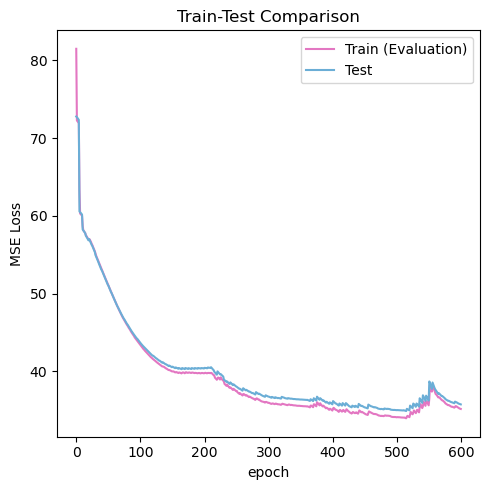

In [28]:
train_eval_df = trainer.stats['train_eval'].copy()
test_df = trainer.stats['test'].copy()

# TODO: remove this prior to full visualization
train_eval_df = train_eval_df.groupby(['epoch']).mean().reset_index()
test_df = test_df.groupby(['epoch']).mean().reset_index()

train_eval_df['loss_type'] = 'Train (Evaluation)'
test_df['loss_type'] = 'Test'

palette = sns.color_palette([
    "#e377c2",  # Pink
    "#6baed6",  # light blue
])


fig, ax = plt.subplots(figsize = (5, 5))

viz_df = pd.concat([train_eval_df, test_df], axis = 0)
viz_df.reset_index(drop = True, inplace = True)
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, 
                                  categories = ['Train (Evaluation)', 'Test'])

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss_full', hue = 'loss_type', 
             palette = palette,
             ax = ax)
ax.set_title('Train-Test Comparison')
ax.set_ylabel('MSE Loss')
ax.legend(title=None)

fig.tight_layout()

### Network Noise

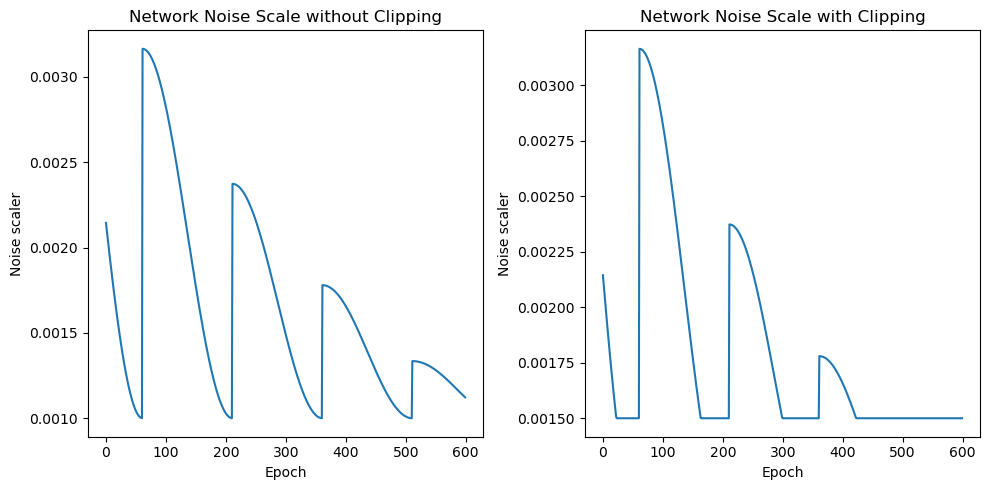

In [29]:
import copy
trainer_2 = copy.deepcopy(trainer)

min_network_noise = trainer_2.hyper_params['min_network_noise']

noise_tracker = []
noise_tracker_unclipped = []
for e in range(trainer_2.hyper_params['max_epochs']):
    cur_lr = trainer_2.prediction_optimizer.param_groups[0]['lr']
    noise_scale = trainer_2.hyper_params['network_noise_scale']*cur_lr/trainer_2.lr_scheduler.max_lr
    noise_tracker_unclipped.append(noise_scale)
    noise_tracker.append(max(noise_scale, min_network_noise))
    trainer_2.lr_scheduler.step()

fig, ax = plt.subplots(ncols = 2, figsize = (10, 5))

sns.lineplot(noise_tracker_unclipped, ax = ax[0])
ax[0].set_title('Network Noise Scale without Clipping')

sns.lineplot(noise_tracker, zorder = 0, ax = ax[1])
# ax[1].hlines(
#     min_network_noise,
#     xmin = 0,  xmax=len(noise_tracker) - 1,
#     color = 'red', linestyle = '--', zorder = 1)
ax[1].set_title('Network Noise Scale with Clipping')

for i in range(2):
    ax[i].set_ylabel('Noise scaler')
    ax[i].set_xlabel('Epoch')
fig.tight_layout()
;
del trainer_2

### Gradient noise

''

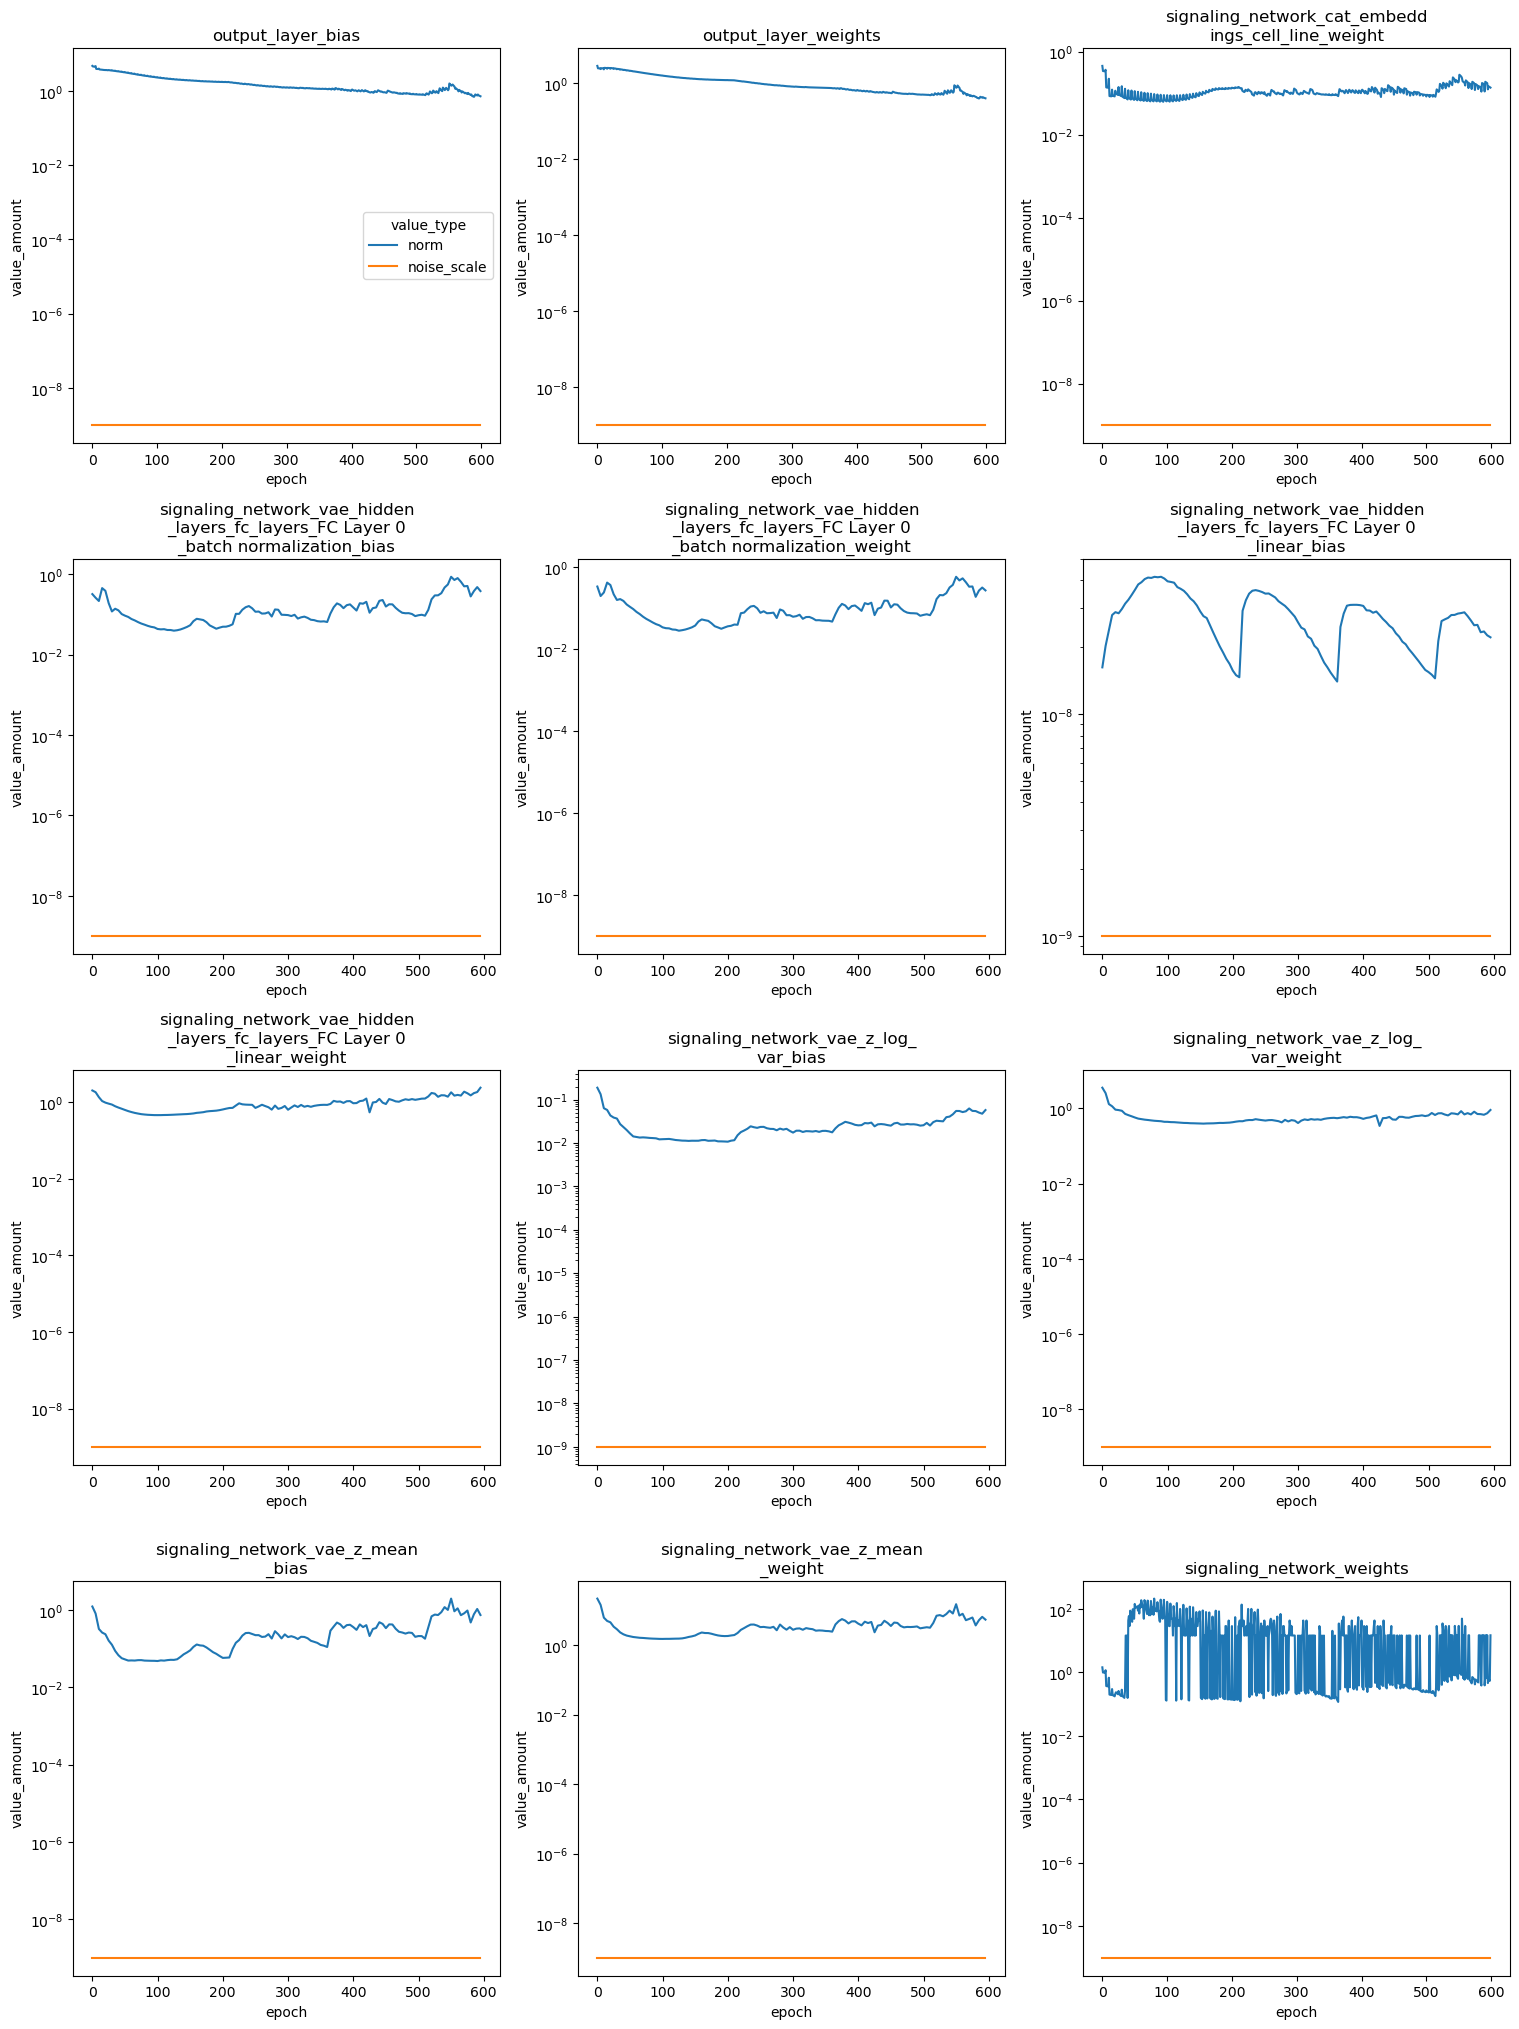

In [30]:
gradient_noise = trainer.stats['gradient_noise'].copy()
gradient_noise = gradient_noise.groupby('epoch').mean().reset_index() # DELETE THIS


noise_layers = [col for col in gradient_noise.columns if col not in ['epoch', 'batch_index']]
noise_layers = sorted(set([nl.split('_norm')[0].split('_noise_scale')[0] for nl in noise_layers]))

# NaN untrained discrimintor epochs for visualization purposes
keep_idx = (gradient_noise.epoch) % n_discriminator_train == 0
for col in noise_layers:
    if not ('output' in col) and not ('cat_embeddings' in col):
        for subtype in ['_norm', '_noise_scale']:
            gradient_noise[col + subtype] = gradient_noise[col + subtype].mask(
                (~keep_idx) & (gradient_noise[col + subtype] == 0), 
                np.nan
            )

ncols = 3
nrows = math.ceil(len(noise_layers)/3)

fig, axes = plt.subplots(ncols = ncols, nrows = nrows, squeeze=False,
                         figsize = (5.1*ncols, 5.1*nrows))
ax = axes.flatten()

for i, noise_layer in enumerate(noise_layers):

    vcols=[col for col in gradient_noise.columns if col == 'epoch' or col.startswith(noise_layer)]
    viz_df = gradient_noise[vcols].copy()

    viz_df = pd.melt(viz_df, id_vars = 'epoch', var_name='value_type', value_name='value_amount')
    viz_df.value_type = pd.Categorical(viz_df.value_type.apply(lambda x: x.split(noise_layer + '_')[1]), 
                                       categories = ['norm', 'noise_scale'], 
                                       ordered = True)
    sns.lineplot(data = viz_df, x = 'epoch', y = 'value_amount', hue = 'value_type', 
                   ax = ax[i])
    ax[i].set_yscale('log')
    if i != 0:
        ax[i].legend().remove()

    title_length = 28
    if len(noise_layer) > title_length:
        title = '\n'.join([noise_layer[i_:i_+28] for i_ in range(0, len(noise_layer), 28)])
    else:
        title = noise_layer
    ax[i].set_title(title)
fig.tight_layout()
;


## 2. Adversarial Assessments

In [31]:
import joblib 

import umap

import torch.nn.functional as F

import Tahoe_utils as Tu 

from scLEMBAS import preprocess as pp

### Adversarial Penalty Schedule

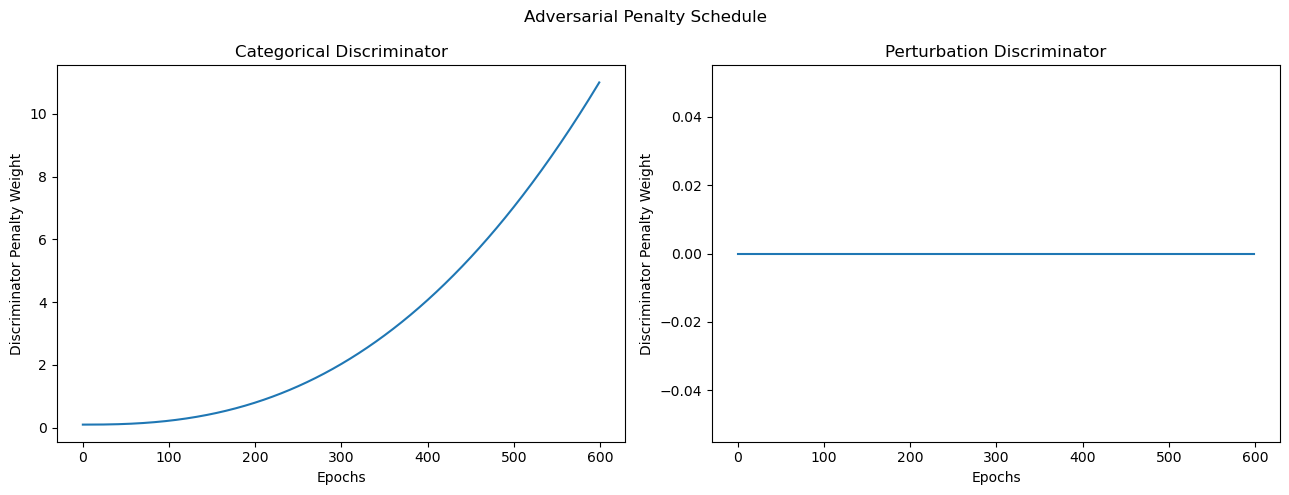

In [32]:
fig, ax = plt.subplots(ncols = 2, figsize = (13,5))
sns.lineplot(trainer.cat_discriminator['params']['discriminator_penalty_weight'], ax = ax[0])
ax[0].set_title('Categorical Discriminator')


sns.lineplot(trainer.pert_discriminator['params']['discriminator_penalty_weight'], ax = ax[1])
ax[1].set_title('Perturbation Discriminator')

for i in range(2):
    ax[i].set_xlabel('Epochs')
    ax[i].set_ylabel('Discriminator Penalty Weight')
    
    if n_adversarial_start != 0:
        ax[i].vlines(n_adversarial_start, ymin = 0, ymax = ax[1].get_ylim()[1], color = 'red', linestyle = '--')

fig.suptitle('Adversarial Penalty Schedule')    
fig.tight_layout();

### Discriminator and Generator Gradient

- Discriminator: Bad if L2 norm is > 100 (see number [10](https://github.com/soumith/ganhacks))
- Generator: if gradient disappears quick (standard GANs), not able to learn anything

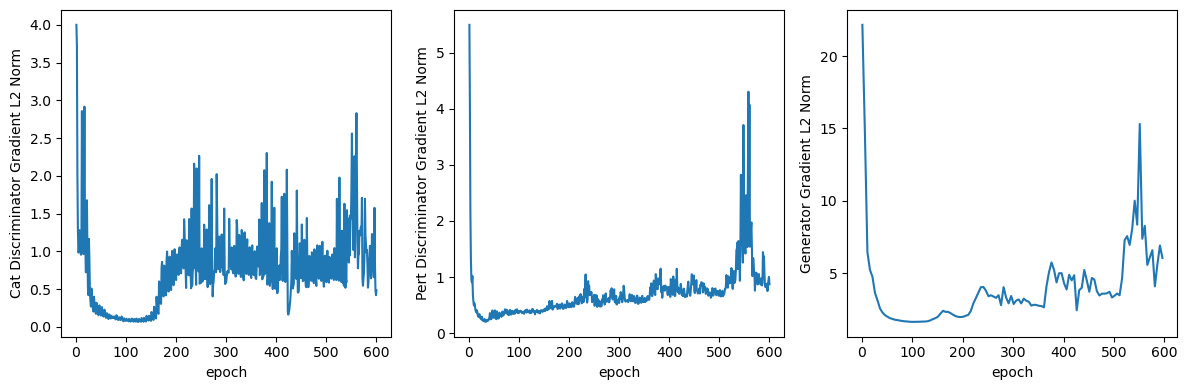

In [33]:
fig, ax = plt.subplots(ncols = 3, figsize = (12, 4))

sns.lineplot(data = train_stats_df, x = 'epoch', 
             y = 'cat_' + cat_col + '_discriminator_grad_l2_norm', ax = ax[0])
ax[0].set_ylabel('Cat Discriminator Gradient L2 Norm')

sns.lineplot(data = train_stats_df, x = 'epoch', 
             y = 'pert_discriminator_grad_l2_norm', ax = ax[1])
ax[1].set_ylabel('Pert Discriminator Gradient L2 Norm')

sns.lineplot(data = train_stats_df, x = 'epoch', 
             y = 'vae_grad_l2_norm', ax = ax[2])
ax[2].set_ylabel('Generator Gradient L2 Norm')

fig.tight_layout()

### Adversarial Loss Curves

Note, for gradient ascent, we switch the signs of the adversarial penalty to be consistent with non gradient ascent visualizations (reconstruction > total loss with adversarial). However, mathematically, since we are now minimizing the discriminator error, the raw curves would show total loss > reconstruction. 

''

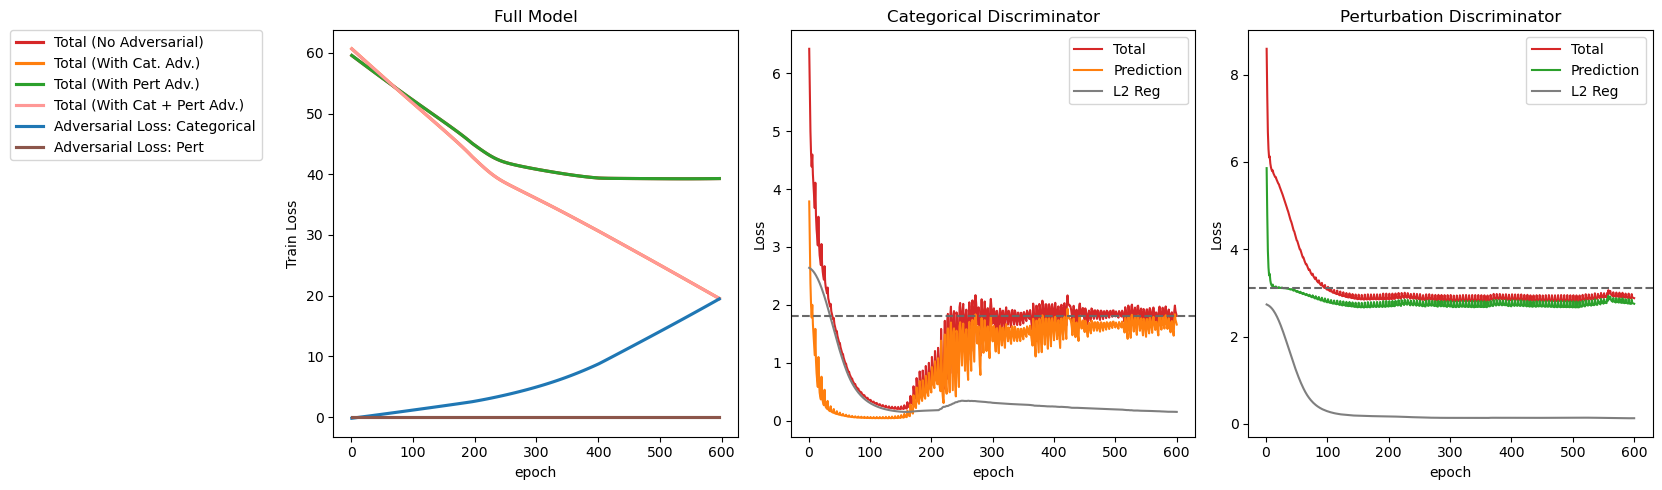

In [34]:
fig, ax = plt.subplots(ncols = 3, figsize = (16.5,5))
ax = ax.flatten()

colors = [
    "#d62728",  # Red
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#ff9896",   # Light red
    "#1f77b4",  # Blue
    "#8c564b",  # Brown
    "#17a589",  #  Teal 
    "#bcbd22",  # Olive
    "#9467bd",  # Purple
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#6baed6",  # light blue

]
palette = sns.color_palette(colors)


# Plot 1: full model, adverserial loss
loss_cols_main = ['sign_reg_loss',
       'stability_reg_loss', 'uniform_reg_loss', 'input_param_reg_loss',
       'sn_param_reg_tot_loss', 'output_param_reg_tot_loss', 'vae_param_reg_loss', 
    'global_bias_kl_divergence']


loss_cols = ['train_loss_total'] + loss_cols_main + ['cat_adverserial_loss', 'pert_adverserial_loss', 'train_loss_prediction']

viz_df = train_stats_df[['epoch'] + loss_cols].copy()
viz_df['total_train_loss_no_adverserial'] = viz_df[loss_cols_main + ['train_loss_prediction']].sum(axis = 1)

viz_df.drop(columns = loss_cols_main, inplace = True)
viz_df.drop(columns = ['train_loss_prediction'], inplace = True)

# for visualization, switch
if trainer.gradient_ascent:
    for adv_col in ['cat_adverserial_loss', 'pert_adverserial_loss']:
        viz_df[adv_col] = viz_df[adv_col].abs()
    viz_df['train_loss_total'] = viz_df.total_train_loss_no_adverserial - viz_df.cat_adverserial_loss - viz_df.pert_adverserial_loss

viz_df['train_loss: total - cat_adverserial'] = viz_df.total_train_loss_no_adverserial - viz_df.cat_adverserial_loss
viz_df['train_loss: total - pert_adverserial'] = viz_df.total_train_loss_no_adverserial - viz_df.pert_adverserial_loss

# without this, the total loss without adversarial does not look accurate
viz_df = viz_df[(viz_df.epoch - 1) % n_discriminator_train == 0]


viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')


loss_cols_sub = ['total_train_loss_no_adverserial',
                 'train_loss: total - cat_adverserial', 
                 'train_loss: total - pert_adverserial',
                 'train_loss_total', 
#                  'train_loss_prediction',
                 'cat_adverserial_loss',
                 'pert_adverserial_loss']
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=loss_cols_sub)

loss_cols_name = [
    'Total (No Adversarial)', 
    'Total (With Cat. Adv.)', 
    'Total (With Pert Adv.)',
    'Total (With Cat + Pert Adv.)', 
#     'Prediction', 
    'Adversarial Loss: Categorical', 
    'Adversarial Loss: Pert'
]

viz_df.loss_type = viz_df.loss_type.map(dict(zip(loss_cols_sub, loss_cols_name)))

for lti, loss_type in enumerate(loss_cols_name):
    sns.regplot(data = viz_df[viz_df.loss_type == loss_type], 
                x = 'epoch', y = 'loss', 
                lowess = True, scatter = False, 
                color = palette[lti], ax = ax[0], label = loss_type)

ax[0].legend(loc='upper left', bbox_to_anchor=(-0.8, 1), borderaxespad=0.)
ax[0].set_ylabel('Train Loss')
ax[0].set_title('Full Model')

# Plot 2: full model, categorical discriminator loss
loss_cols_disc = ['cat_discriminator_loss_total',
       'cat_discriminator_loss_prediction', 'cat_discriminator_param_reg_loss']

viz_df = train_stats_df[['epoch'] + loss_cols_disc].copy()
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=loss_cols_disc)

loss_cols_name = ['Total', 'Prediction', 'L2 Reg']
viz_df.loss_type = viz_df.loss_type.map(dict(zip(loss_cols_disc, loss_cols_name)))

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', 
             palette = [palette[0], palette[1], palette[-2]], ax = ax[1])

cp = tf_adata[train_cells,:].obs[cat_col].value_counts(normalize = True).values
rand_loss = trainer.cat_discriminator['discriminators'][cat_col].random_loss(class_probs = cp)
ax[1].axhline(y=rand_loss, color='dimgray', linestyle='--')

ax[1].legend(loc='best')
ax[1].set_ylabel('Loss')
ax[1].set_title('Categorical Discriminator')


# Plot 3: full model, perturbation discriminator loss
loss_cols_disc = ['pert_discriminator_loss_total',
       'pert_discriminator_loss_prediction', 'pert_discriminator_param_reg_loss']

viz_df = train_stats_df[['epoch'] + loss_cols_disc].copy()
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=loss_cols_disc)

loss_cols_name = ['Total', 'Prediction', 'L2 Reg']
viz_df.loss_type = viz_df.loss_type.map(dict(zip(loss_cols_disc, loss_cols_name)))


sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', 
             palette = [palette[0], palette[2], palette[-2]], ax = ax[2])

cp = tf_adata[train_cells,:].obs[pert_col].value_counts(normalize = True).values
rand_loss = trainer.pert_discriminator['discriminator'].random_loss(class_probs = cp)

ax[2].axhline(y=rand_loss, color='dimgray', linestyle='--')


ax[2].legend(loc='best')
ax[2].set_ylabel('Loss')
ax[2].set_title('Perturbation Discriminator')


fig.tight_layout()
# plt.savefig(os.path.join(data_path, 'trash', fn + '_loss_adverserial' + '.png'), dpi=300, bbox_inches='tight')
;



### Adversarial Loss Embedding

Get the bias output of the model predictions for the test with perturbation counterfactuals and the train with no counterfactuals:

In [35]:
test_bias = Tu.get_prediction(
    mod = mod,
    train_cells = trainer.X_train.index.tolist(),
    test_cells = trainer.X_test.index.tolist(), 
    tf_adata = tf_adata,
    cat_col = cat_col,
    pert_col = pert_col ,
    ctrl_pert = 'DMSO_TF', 
    counterfactual = 'perturbation',
    cat_counterfactual_map = None,
    remove_type = 'none',
    return_bias = True, 
    max_cells = int(5e3), 
    return_full = False,
)

train_bias = Tu.get_prediction(
    mod = mod,
    train_cells = trainer.X_train.index.tolist(),
    test_cells = trainer.X_test.index.tolist(), 
    tf_adata = tf_adata,
    cat_col = cat_col,
    pert_col = pert_col ,
    ctrl_pert = 'DMSO_TF', 
    counterfactual = None,
    cat_counterfactual_map = None,
    remove_type = 'none',
    return_bias = True, 
    max_cells = int(5e3), 
    return_full = False,
)

biases_res = {'test': test_bias, 
              'train': train_bias}

Set up inputs for prediction


100%|███████████████████████████████████| 29/29 [00:06<00:00,  4.69it/s]


Get the predictions
Set up inputs for prediction


100%|█████████████████████████████████| 261/261 [00:58<00:00,  4.49it/s]


Get the predictions


100%|█████████████████████████████████████| 6/6 [00:00<00:00,  6.52it/s]


- <span style="color:red">If using PLS, will want to calculate the number of components as in 03B</span>

In [36]:
# TODO: replace with getting the knee estimation for # of components as in 03B
pls_model_all = joblib.load(os.path.join(data_path, 'processed', author + '_drug_pls_model.joblib'))
n_pls_components = pls_model_all.n_components


biases_clustered = {}
for split_type, br in biases_res.items():
    print(split_type)
    bias_global, _, _, bias_cats, bias_tot, obs = br
    
    if bias_global.shape[0] < 50:
        n_components = 10
    else:
        n_components = 50
    

    # global bias
    bias_global = sc.AnnData(X = bias_global.detach().cpu().numpy(), obs = obs)
    pp.embed_tf_activity(bias_global, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1,
                     n_components = n_components)
    
    # get the PLS-DA for global bias since perturbation doesn't separate well with PCA
    models, _, X_pls = Tu.pls_da(
        adata = bias_global,
        n_components = n_pls_components,
        control_confounders = True,
        assess = False,
        return_components = True,
        seed = seed,
        enc_X = None,
        enc_Y = None)

    umap_model = umap.UMAP(
        n_neighbors=15, 
        n_components=2,
        metric='euclidean', 
        target_metric='categorical', 
        random_state = seed)
    umap_model.fit(X_pls,
                   bias_global.obs['drug'].cat.codes.values)
    embedding = umap_model.transform(X_pls)
    models['umap_pls'] = umap_model

    bias_global.uns['pls'] = {'models': models, 
                             'X_pls': X_pls, 
                             'umap_embedding': embedding}

    # total bias 
    bias_tot = sc.AnnData(X = bias_tot.detach().cpu().numpy().T, obs = obs)
    pp.embed_tf_activity(bias_tot, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1,
                     n_components = n_components)

    # categorical bias
    bias_cats = sc.AnnData(X = bias_cats.detach().cpu().numpy().T, obs = obs)
    pp.embed_tf_activity(bias_cats, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1, 
                     n_components = n_components)

    biases_clustered[split_type] = (bias_global, bias_tot, bias_cats)

io.write_pickled_object(biases_clustered,  
                        os.path.join(data_path, 'trash', fn + author + '_clustered_biases.pickle'))

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


test


/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/home/hmbaghda/Projects/scLEMBAS/scLEMBAS/preprocess.py:311: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata = tf_adata, resolution = resolution) # cluster
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for paralleli

train


/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEM

In [37]:
biases_clustered = io.read_pickled_object(os.path.join(data_path, 
                                                       'trash', fn + author + '_clustered_biases.pickle'))

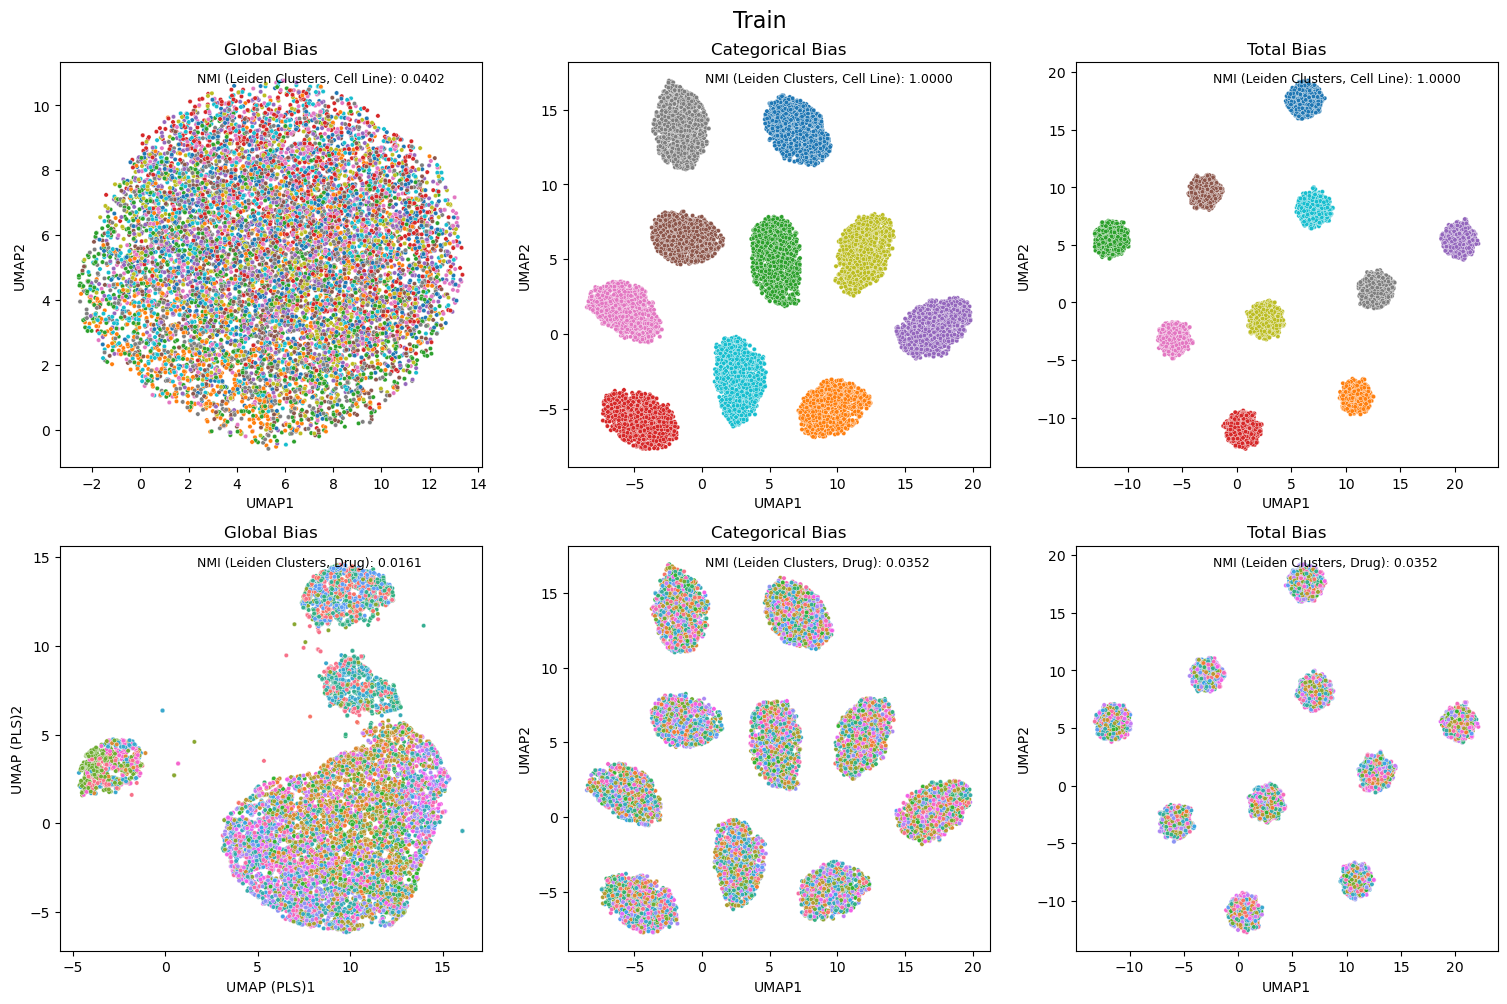

In [38]:
split_type = 'train'

bias_types = dict(zip(
    ['Global', 'Categorical', 'Total'],
    biases_clustered[split_type]
))

cat_map = {
    cat_col: ' '.join([cc.capitalize() for cc in cat_col.split('_')]), 
    pert_col: ' '.join([cc.capitalize() for cc in pert_col.split('_')])
}

ncols, nrows = len(bias_types), len(cat_map)

fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (ncols *5.1, nrows*5.1))
for j, (bias_type, bias) in enumerate(bias_types.items()):
    for i, cat in enumerate(cat_map):
        
        reduction_type = 'umap'
        if bias_type == 'Global' and cat == 'drug':
            reduction_type = 'umap_pls'
        viz_df, nmi = Tu.adata_dimviz_bias(adata = bias,
                                reduction_type = reduction_type,
                                cat = cat,
                                subset_size = int(1e4), 
                               seed = seed)
        
        sns.scatterplot(data = viz_df, x = viz_df.columns[0], y = viz_df.columns[1], hue = cat, 
                        s=10,
                        ax = ax[i,j])
        ax[i,j].annotate('NMI (Leiden Clusters, ' + cat_map[cat] + '): {:.4f}'.format(nmi),
                        xy = (0.325, 0.95), xycoords='axes fraction', fontsize = 9)
        ax[i,j].set_title(bias_type + ' Bias')
        
        ax[i,j].legend_.remove()

fig.suptitle(split_type.capitalize(), fontsize=16)
fig.tight_layout();

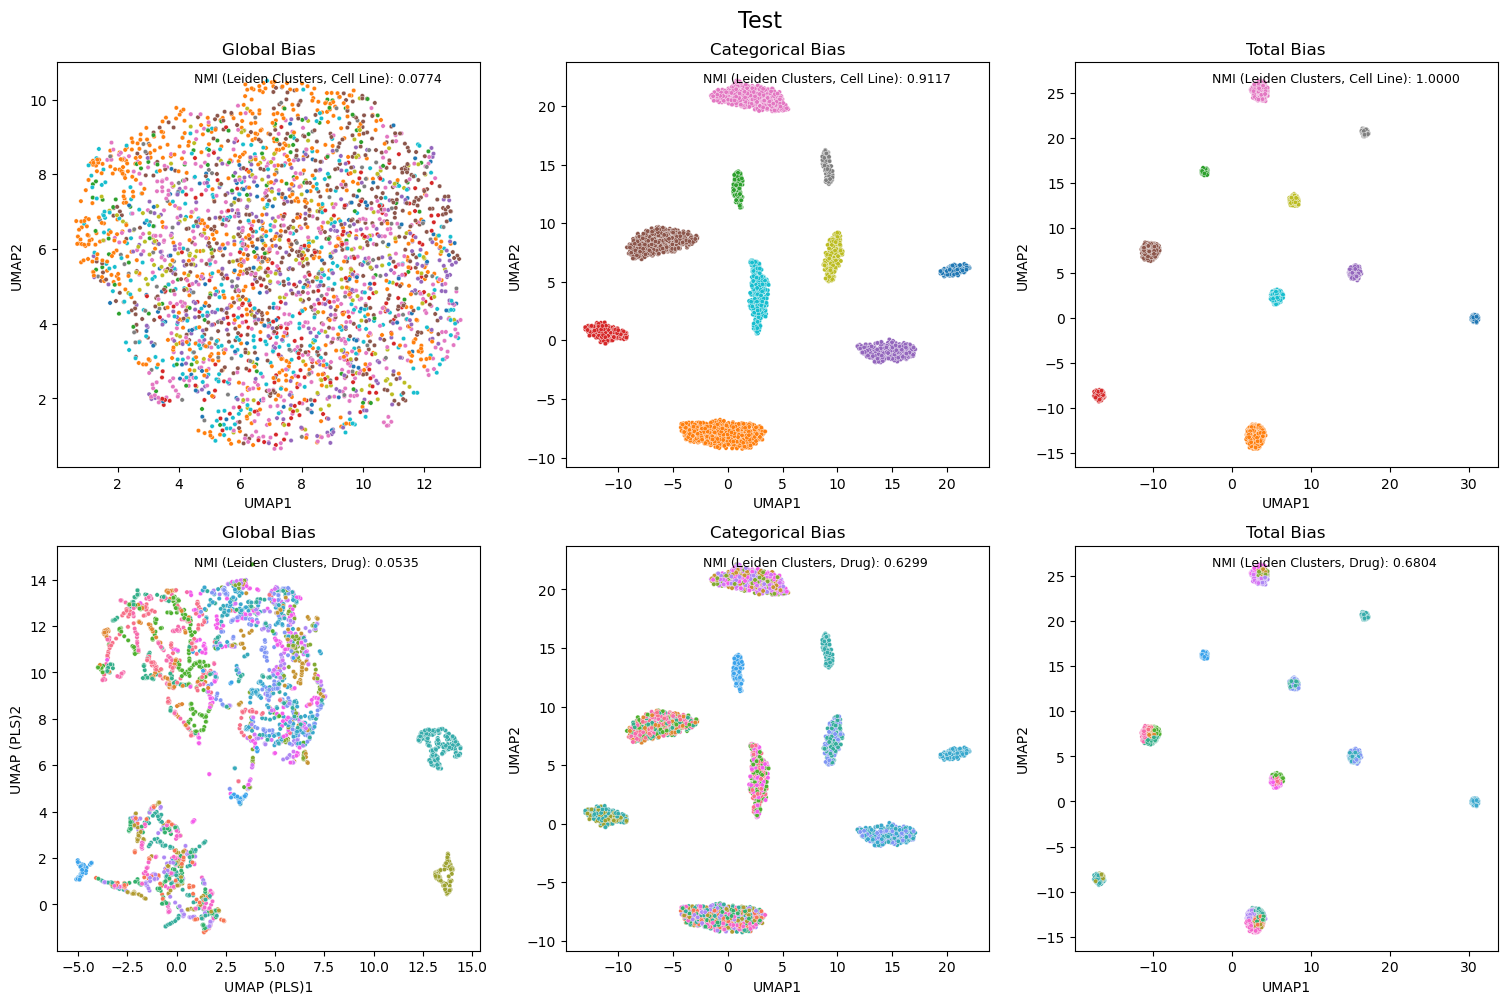

In [40]:
split_type = 'test'

bias_types = dict(zip(
    ['Global', 'Categorical', 'Total'],
    biases_clustered[split_type]
))

cat_map = {
    cat_col: ' '.join([cc.capitalize() for cc in cat_col.split('_')]), 
    pert_col: ' '.join([cc.capitalize() for cc in pert_col.split('_')])
}

ncols, nrows = len(bias_types), len(cat_map)

fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (ncols *5.1, nrows*5.1))
for j, (bias_type, bias) in enumerate(bias_types.items()):
    for i, cat in enumerate(cat_map):
        
        reduction_type = 'umap'
        if bias_type == 'Global' and cat == 'drug':
            reduction_type = 'umap_pls'
        
        viz_df, nmi = Tu.adata_dimviz_bias(adata = bias,
                                reduction_type = reduction_type,
                                cat = cat,
                                subset_size = int(1e4), 
                               seed = seed)
        
        sns.scatterplot(data = viz_df, x = viz_df.columns[0], y = viz_df.columns[1], hue = cat,
                        s=10,
                        ax = ax[i,j])
        ax[i,j].annotate('NMI (Leiden Clusters, ' + cat_map[cat] + '): {:.4f}'.format(nmi),
                        xy = (0.325, 0.95), xycoords='axes fraction', fontsize = 9)
        ax[i,j].set_title(bias_type + ' Bias')
        
        ax[i,j].legend_.remove()

fig.suptitle(split_type.capitalize(), fontsize=16)
fig.tight_layout();

### Adversarial Loss Probe Classifier

Use a linear and non-linear probe classifier to quantify the extent of information removal in the global bias

We see how well a second classifier (both linear - LogisticRegression and nonlinear - RandomForest) trained on the global bias can achieve separation using 5-fold CV. This is because despite seeing decent mixing in the UMAP/NMI, we still see that the full model forward pass can separate using global bias in some instances. If the secondary classifier is random, we know we have information removal. 

Randome baseline comparison: For unbalanced classes, if classifiers learned completely random data, we'd expect their accuracy to equal the proportion of the majority class in the dataset.


- <span style="color:red">Will want to do this for the bionet and full forward output as done in Kang at some point</span>
- <span style="color:red">Will want to do for a model with no adversarial training as a comparison</span>
- <span style="color:red">Use the random baseline in the 5-fold CV loop (rather then getting the direct one in the tf_adata obejct) to get a statistical significance comparison</span>


In [41]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

from tqdm import tqdm

In [42]:
biases_clustered = io.read_pickled_object(
    os.path.join(data_path, 'trash', fn + author + '_clustered_biases.pickle'))

In [43]:
%%time
n_folds = 5
counter = 0

probe_res = pd.DataFrame(columns=['split_type', 'linear_accuracy', 'nonlinear_accuracy'])

# train and test
for split_type, br in biases_clustered.items():
    bias_global = br[0]
    X_full = bias_global.to_df().to_numpy()
    obs = bias_global.obs
    
    categories = {
        cat_col: obs[cat_col],
        pert_col: obs[pert_col]
    }
    
    # cell line and perturbation
    for category_name, category_labels in categories.items():
        if category_name == 'drug': # use pls fit on the generator output
            X = bias_global.uns['pls']['X_pls']
        else: # use the direct generator output
            X = X_full

        skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
        
        y = category_labels.to_numpy()
        
        # 5-fold CV
        for train_idx, test_idx in tqdm(skf.split(X, y)):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            
#             # subset for accelerated training
#             n_samples = X_train.shape[0]
#             subset_size = int(0.05 * n_samples)
#             subset_indices = np.random.choice(n_samples, size=subset_size, replace=False)
#             X_train = X_train[subset_indices]
#             y_train = y_train[subset_indices]

            # linear probe
            probe_linear = LogisticRegression(max_iter=2000, solver='lbfgs', multi_class='auto', 
                                              random_state=seed)
            probe_linear.fit(X_train, y_train)

            y_pred = probe_linear.predict(X_test)
            linear_accuracy = accuracy_score(y_test, y_pred)
            
            # nonlinear probe
            probe_nonlinear = RandomForestClassifier(
                n_estimators=100,          
                max_depth=None,            
                random_state=seed,
                n_jobs=n_cores,                 
                verbose=False                  
            )
            probe_nonlinear.fit(X_train, y_train)
            y_pred = probe_nonlinear.predict(X_test)
            nonlinear_accuracy = accuracy_score(y_test, y_pred)
            
        
#             mlp_probe = MLPClassifier(hidden_layer_sizes=(100,),
#                                       activation='relu', 
#                                       solver = 'adam', 
#                                       max_iter=500, 
#                                      shuffle = True, 
#                                      random_state = seed_split)
#             mlp_probe.fit(X_train, y_train)
#             y_pred = mlp_probe.predict(X_test)
#             nonlinear_accuracy = accuracy_score(y_test, y_pred)

#             # get the random baseline -- can be estimated from obs directly
#             y_counts = np.bincount(LabelEncoder().fit_transform(y_train))
#             baseline_accuracy = y_counts.max() / y_counts.sum()
            
            probe_res.loc[counter, 'prediction_category'] = category_name
            probe_res.loc[counter, 'split_type'] = split_type
            probe_res.loc[counter, 'linear_accuracy'] = linear_accuracy
            probe_res.loc[counter, 'nonlinear_accuracy'] = nonlinear_accuracy
            
            
            
            counter += 1

probe_res.to_csv(os.path.join(data_path, 'trash', fn + '_' + author + '_probe.csv'))

5it [00:18,  3.76s/it]
5it [00:02,  1.71it/s]
5it [04:33, 54.73s/it]
5it [00:22,  4.57s/it]

CPU times: user 1h 34min 2s, sys: 1.05 s, total: 1h 34min 3s
Wall time: 5min 18s


In [44]:
probe_res = pd.read_csv(os.path.join(data_path, 'trash', fn + '_' + author + '_probe.csv'), 
                       index_col = 0)

probe_res = pd.melt(probe_res, id_vars = ['split_type', 'prediction_category'], 
                    var_name='Classifier Type', value_name='Accuracy')

# formatting
probe_res['Classifier Type'] = pd.Categorical(
    probe_res['Classifier Type'].apply(lambda x: x.split('_')[0].capitalize()), 
    categories = ['Linear', 'Nonlinear'], 
    ordered = True                                       
)
probe_res.split_type = pd.Categorical(
    probe_res.split_type.apply(lambda x: x.capitalize()), 
    categories = ['Train', 'Test'], 
    ordered = True
)

probe_res['prediction_category'] = pd.Categorical(
    probe_res['prediction_category'].apply(lambda x: ' '.join([cc.capitalize() for cc in x.split('_')])), 
    categories = ['Cell Line', 'Drug'], 
    ordered = True                                       
)

''

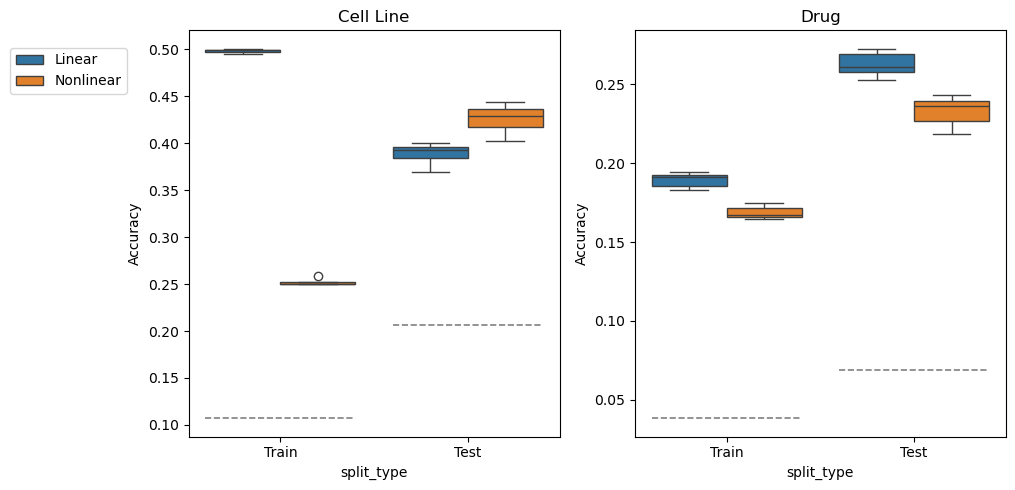

In [45]:
ncols = probe_res.prediction_category.nunique()

# random baseline is just guess the maximum frequency category
random_baselines = {
    'Train': {
        ' '.join([cc.capitalize() for cc in cat_col.split('_')]): tf_adata[train_cells, :].obs[cat_col].value_counts(normalize = True).max(), 
        pert_col.capitalize(): tf_adata[train_cells, :].obs[pert_col].value_counts(normalize = True).max(), 
    },
    'Test': {
        ' '.join([cc.capitalize() for cc in cat_col.split('_')]): tf_adata[test_cells, :].obs[cat_col].value_counts(normalize = True).max(), 
        pert_col.capitalize(): tf_adata[test_cells, :].obs[pert_col].value_counts(normalize = True).max(), 
    }   
}


fig, ax = plt.subplots(ncols = ncols, figsize = (ncols*5.1, 5))
for j, pc in enumerate(probe_res.prediction_category.cat.categories):
    viz_df = probe_res[probe_res.prediction_category == pc]
    
    sns.boxplot(data = viz_df, 
                x = 'split_type', 
                y = 'Accuracy', 
                hue = 'Classifier Type', 
                ax = ax[j], zorder = 0)
    
    # add random baselines
    for split_type in viz_df['split_type'].cat.categories:
        baseline = random_baselines[split_type][pc] 
        x_positions = [i for i, label in enumerate(viz_df['split_type'].cat.categories) if label == split_type]
        for x in x_positions:
            ax[j].hlines(baseline, xmin=x-0.4, xmax=x+0.4, 
                         color='gray', linestyle='--', linewidth=1.2, label=None, zorder = 1)
            
    if j == 1:
        ax[j].get_legend().remove()
    elif j == 0:
        ax[j].legend(loc='center left', bbox_to_anchor=(-0.5, 0.9))
        
    ax[j].set_title(pc)
    
fig.tight_layout()
;



## 3. Prediction Projections

Observing visualization of predictions projected into an embedding is a highly informative first pass of accurate predictions, as quantitative metrics can sometimes seemingly indicate reasonable predictions but are missing some key global/local distribution component. 

- <span style="color:red">Will want to repeat for cell type counterfactual</span>
- <span style="color:red">For internal assessment, may want to see what the trains with counterfactual look like</span>

In [46]:
remove_types = ['none',
                     ['adj', 'categorical_bias'],
                     ['adj', 'global_bias'],
                     'total_bias', 
                     'adj',
                     'categorical_bias',
                     'global_bias']

In [49]:
for remove_type in tqdm(remove_types):
    tf_adata_predicted = Tu.get_prediction(
        mod = mod,
        train_cells = trainer.X_train.index.tolist(),
        test_cells = trainer.X_test.index.tolist(), 
        tf_adata = tf_adata,
        cat_col = cat_col,
        pert_col = pert_col ,
        ctrl_pert = 'DMSO_TF', 
        counterfactual = 'perturbation',
        cat_counterfactual_map = None,
        remove_type = 'none',
        return_bias = False, 
        max_cells = int(5e3), 
        return_full = False,
    )
    
    break

  0%|                                             | 0/7 [00:00<?, ?it/s]

Set up inputs for prediction



100%|███████████████████████████████████| 29/29 [00:07<00:00,  3.63it/s]


Get the predictions


/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
  0%|                                             | 0/7 [00:09<?, ?it/s]


In [68]:
get_loss(tf_adata, tf_adata_predicted)

{'CVCL_0023^Rapamycin': 85.92117309570312,
 'CVCL_0371^Bexarotene': 88.1930160522461,
 'CVCL_0371^Clonidine (hydrochloride)': 82.16024780273438,
 'CVCL_0371^Gefitinib': 88.49237060546875,
 'CVCL_0371^Neratinib (maleate)': 88.32987213134766,
 'CVCL_0371^Rucaparib (phosphate)': 97.05773162841797,
 'CVCL_0371^Tucidinostat': 94.65149688720703,
 'CVCL_0399^Regorafenib': 99.11212158203125,
 'CVCL_0459^Crizotinib (hydrochloride)': 93.50264739990234,
 'CVCL_0459^Norepinephrine (hydrochloride)': 101.88735961914062,
 'CVCL_0480^Piroxicam': 78.30361938476562,
 'CVCL_0480^Rapamycin': 79.97698974609375,
 'CVCL_0480^Retinoic acid': 80.04130554199219,
 'CVCL_0546^Almonertinib (mesylate)': 104.10910034179688,
 'CVCL_0546^Binimetinib': 107.81256866455078,
 'CVCL_0546^Filgotinib': 93.36274719238281,
 'CVCL_0546^Naproxen': 102.04655456542969,
 'CVCL_0546^Vilanterol': 103.75880432128906,
 'CVCL_1056^Cabozantinib (S-malate)': 75.89158630371094,
 'CVCL_1056^Dabrafenib': 75.94376373291016,
 'CVCL_1056^Rucapa

In [67]:
def get_loss(tf_adata, tf_adata_predicted, device = device):
    """Calculates the loss between predicted and actual data per condition. 
    geom_loss by default normalizes to sample size so that doesn't need to be done. 
    Does take average across conditions for the total loss (rather than simply summing), so that it does not change with 
    the number of conditions 
    """
    loss_fn = SamplesLoss("sinkhorn", p=2, blur=0.05).to(device)
    loss = {}
    conds = tf_adata_predicted.obs.condition.unique()
    for cond in conds:
        y_predicted = torch.tensor(tf_adata_predicted[tf_adata_predicted.obs.condition == cond, ].to_df().values).to(device)
        y_actual = torch.tensor(tf_adata[tf_adata.obs.condition == cond, ].to_df().values).to(device)
        loss[cond] = loss_fn(y_predicted, y_actual)
        utils.clear_memory()
    loss['Mean EMD Loss'] = sum(loss.values())/len(loss) # averaged across condition to not scale with n_conditions
    
    
    return {k: float(v.cpu().numpy()) for k,v in loss.items()}

In [ ]:

train_bias = Tu.get_prediction(
    mod = mod,
    train_cells = trainer.X_train.index.tolist(),
    test_cells = trainer.X_test.index.tolist(), 
    tf_adata = tf_adata,
    cat_col = cat_col,
    pert_col = pert_col ,
    ctrl_pert = 'DMSO_TF', 
    counterfactual = None,
    cat_counterfactual_map = None,
    remove_type = 'none',
    return_bias = True, 
    max_cells = int(5e3), 
    return_full = False,
)

biases_res = {'test': test_bias, 
              'train': train_bias}